In [1]:
from util import *
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso

**Data**

In [2]:
np.random.seed(2025)
n_points = 51

noise = 0.01 * np.random.randn(n_points,1)
x = np.linspace(-1, 1, n_points).reshape(-1,1)
y = Runge(x) + noise

**Recreate the same plot as in C and D**

/mnt/c/users/sande/OneDrive - Universitetet i Oslo/Dokumenter/UiO/fysstk/P1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.202e-02, tolerance: 3.139e-04
  model = cd_fast.enet_coordinate_descent(
/mnt/c/users/sande/OneDrive - Universitetet i Oslo/Dokumenter/UiO/fysstk/P1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.632e-02, tolerance: 2.865e-04
  model = cd_fast.enet_coordinate_descent(
/mnt/c/users/sande/OneDrive - Universitetet i Oslo/Dokumenter/UiO/fysstk/P1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: 

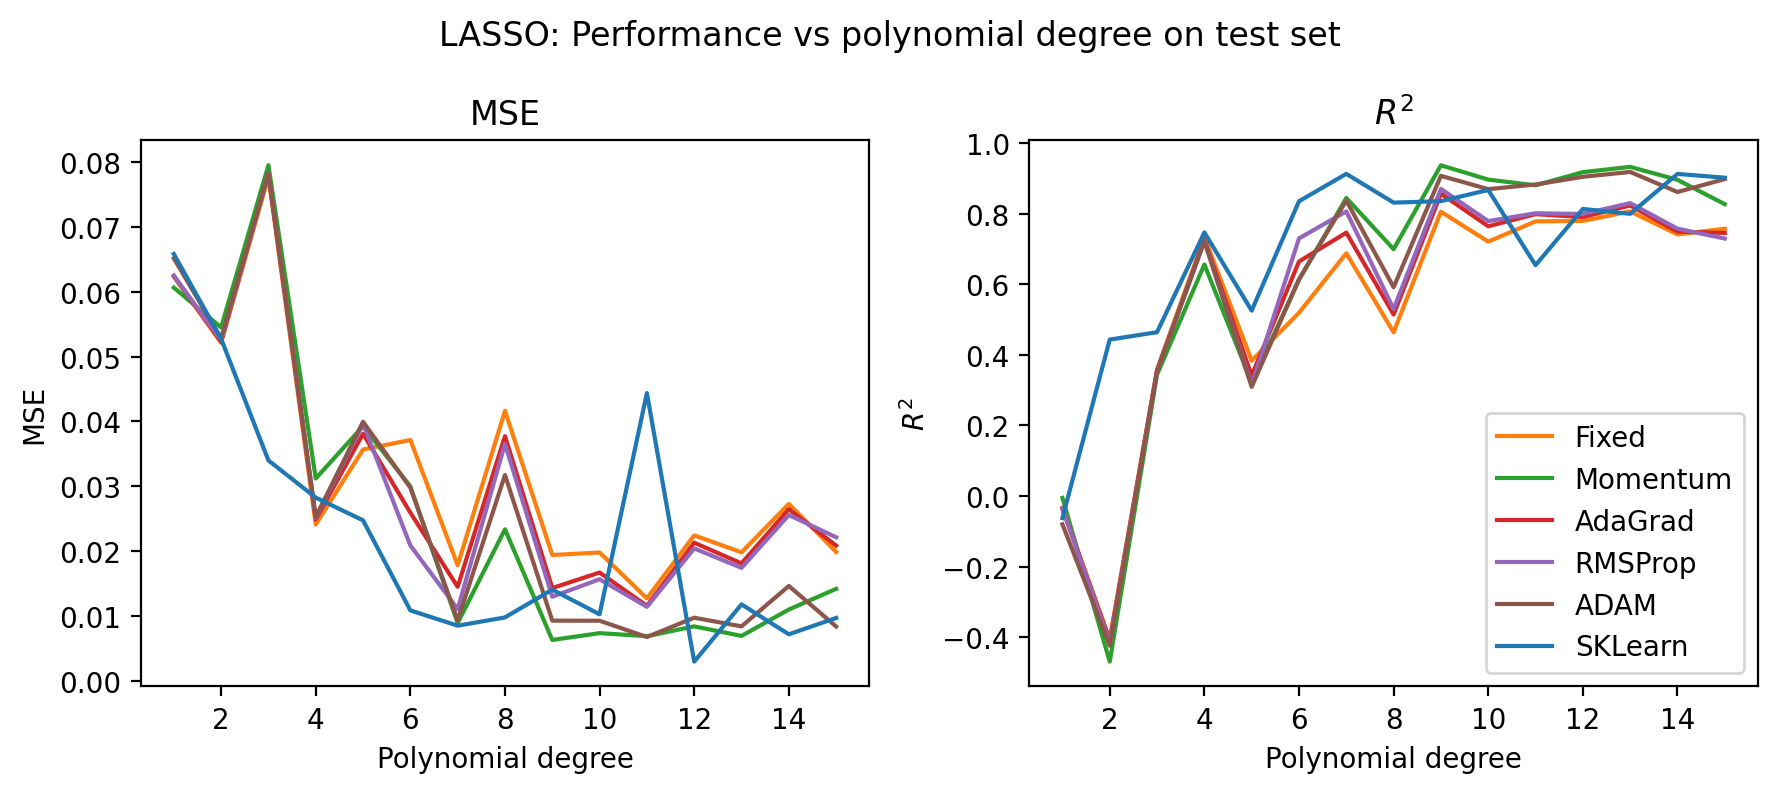

In [3]:
learning_rate = 0.05
l=1e-4
lambdas = np.logspace(-7,0,8)
maxdegree = 15
degrees = np.arange(1,maxdegree + 1)

# Fixed, Momentum, AdaGrad, RMSProp, ADAM
Ridge_mses = []
Ridge_r2s = []
betas = []

for degree in degrees:
    X = PolynomialFeatures(degree = degree).fit_transform(x)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

    # Scaling
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    y_offset = np.mean(y_test)

    Ridge_mses_degree = []
    Ridge_r2s_degree = []

    # Gradient descent solver
    Ridge_grad_descent_solver = gradient_descent(X_train_s, y_train, LASSO_Gradient, learning_rate, hyperparameter = l)

    # Grad descent - fixed learning rate
    theta_grad_descent = Ridge_grad_descent_solver.gradient_descent()
    grad_descent_predictions = X_test_s @ theta_grad_descent + y_offset
    Ridge_r2s_degree.append(r2_score(y_test, grad_descent_predictions))
    Ridge_mses_degree.append(mean_squared_error(y_test,   grad_descent_predictions))

    # Grad descent + momentum
    theta_momentum = Ridge_grad_descent_solver.momentum(alpha = 0.995)
    momentum_predictions = X_test_s @ theta_momentum + y_offset
    Ridge_r2s_degree.append(r2_score(y_test, momentum_predictions))
    Ridge_mses_degree.append(mean_squared_error(y_test, momentum_predictions))

    # Grad descent + AdaGrad
    theta_adagrad = Ridge_grad_descent_solver.AdaGrad()
    adagrad_predictions = X_test_s @ theta_adagrad + y_offset
    Ridge_r2s_degree.append(r2_score(y_test, adagrad_predictions))
    Ridge_mses_degree.append(mean_squared_error(y_test, adagrad_predictions))

    # Grad descent + RMSProp
    theta_rmsprop = Ridge_grad_descent_solver.RMSProp(rho = 0.999)
    rmsprop_predictions = X_test_s @ theta_rmsprop + y_offset
    Ridge_r2s_degree.append(r2_score(y_test,rmsprop_predictions))
    Ridge_mses_degree.append(mean_squared_error(y_test, rmsprop_predictions))

    # Grad descent + ADAM
    theta_adam = Ridge_grad_descent_solver.ADAM(rho1 = 0.9, rho2 = 0.999)
    adam_predictions = X_test_s @ theta_adam + y_offset
    Ridge_r2s_degree.append(r2_score(y_test, adam_predictions))   
    Ridge_mses_degree.append(mean_squared_error(y_test, adam_predictions))

    Ridge_mses.append(Ridge_mses_degree)
    Ridge_r2s.append(Ridge_r2s_degree)

Ridge_mses = np.array(Ridge_mses)
Ridge_r2s = np.array(Ridge_r2s)

methods = ["Fixed", "Momentum", "AdaGrad", "RMSProp", "ADAM"]

fig, ax = plt.subplots(1,2, figsize = (9,4), dpi = 200)
fig.suptitle("LASSO: Performance vs polynomial degree on test set")

ax[0].set_title("MSE")
ax[1].set_title(r"$R^2$")
ax[0].set_xlabel("Polynomial degree")
ax[1].set_xlabel("Polynomial degree")
ax[0].set_ylabel("MSE")
ax[1].set_ylabel(r"$R^2$")

# Set colors to match those of previous parts
colors = ["tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]  
for i, method in enumerate(methods):
    ax[0].plot(degrees, Ridge_mses[:,i], label = method, color=colors[i])
    ax[1].plot(degrees, Ridge_r2s[:,i], label = method, color=colors[i])


# Find the SKLearn Lasso solution for comparison, to keep the random seed
lasso_r2s_sklearn, lasso_mses_sklearn = [],[]
for degree in degrees:
    X = PolynomialFeatures(degree = degree).fit_transform(x)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

    # Scaling
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    y_offset = np.mean(y_test)

    lasso = Lasso(alpha = l, max_iter = 1000, tol = 1e-4)
    lasso.fit(X_train_s, y_train)

    lasso_pred = lasso.predict(X_test_s)
    lasso_r2s_sklearn.append(r2_score(y_test, lasso_pred))
    lasso_mses_sklearn.append(mean_squared_error(y_test, lasso_pred))

ax[0].plot(degrees, lasso_mses_sklearn, label = "SKLearn", color = "tab:blue")
ax[1].plot(degrees, lasso_r2s_sklearn, label = "SKLearn", color = "tab:blue")

ax[1].legend()
fig.tight_layout()